In [ ]:
using Plots
using Random
using StatsPlots
using Turing

Turing.turnprogress(false)
Random.seed!(777);

In [3]:
# Emissions
y = [1.0, 1.0, 1.0, 1.0, 2.0, 2.0, 2.0, 3.0, 3.0, 3.0, 2.0, 2.0, 2.0, 
     1.0, 1.0]
N = length(y)
K = 3

3

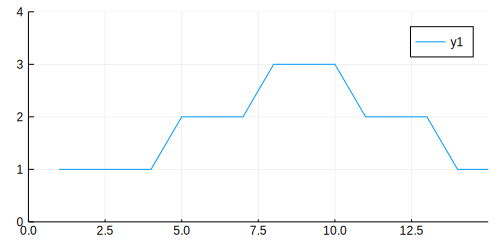

In [5]:
plot(y, xlim=(0, 15), ylim=(0, 4), size=(500, 250))

In [6]:
@model BayesHMM(y, k) = begin
    N = length(y)
    s = tzeros(Int, N)           # observed states
    m = Vector(undef, K)         # emission matrix
    T = Vector{Vector}(undef, K) # transition matrix
    for i = 1:K
        T[i] ~ Dirichlet(ones(K) / K) # prior p(x -> y) same, all (x, y)
        m[i] ~ Normal(i, 0.5)    # p(state i emits i)
    end
    # Observe points in input
    s[1] ~ Categorical(K)
    y[1] ~ Normal(m[s[1]], 0.1)
    for i = 2:N
        s[i] ~ Categorical(vec(T[s[i - 1]]))
        y[i] ~ Normal(m[s[i]], 0.1)
    end
end

(::DynamicPPL.ModelGen{(:y, :k),var"###BayesHMM#303",NamedTuple{(),Tuple{}}}) (generic function with 1 method)

In [ ]:
# Sampler (PG: Particle Gibbs)
g = Gibbs(HMC(0.001, 7, :m, :T), PG(20, :s))
c = sample(BayesHMM(y, 3), g, 100);

In [ ]:
# extract params from chain
ms = c[:m].value.data
ss = c[:s].value.data
N = length(c)

In [ ]:
animation = @animate for i in 1:N
    m = ms[i, :]
    s = Int.(ss[i, :])
    emissions = collect(skipmissing(m[s]))
    p = plot(y,
             c=:red,
             xlabel="Time",
             ylabel="State",
             legend=:topright,
             label="Target",
             xlim=(0, 15),
             ylim=(-1, 5))
    plot!(emissions, color=:blue, label="Sample $$N")
end every 10;

In [ ]:
# how is convergence?
subchain = c[:, ["T[$$i][$$i]" for i in 1:K], :]
plot(subchain,
     colordim=:parameter,
     seriestype=:traceplot,
     title="Persistence Probability", 
     legend=:right)

In [ ]:
# use diagnostics rather than relying on sight
heideldiag(c[:T])